In [ ]:
# Norwegian electricity consumption — monthly data
url = "https://raw.githubusercontent.com/owid/energy-data/master/owid-energy-data.csv"
df_energy = pd.read_csv(url)

# Filter for Norway
norway_energy = df_energy[df_energy['country'] == 'Norway'][
    ['year', 'electricity_demand']
].dropna().reset_index(drop=True)

print(f"Year range: {norway_energy['year'].min()} to {norway_energy['year'].max()}")
print(f"Total rows: {len(norway_energy)}")
display(norway_energy.head(10))

Year range: 1990 to 2025
Total rows: 36


,year,electricity_demand
0,1990,105.69
1,1991,107.79
2,1992,108.38
3,1993,111.94
4,1994,112.19
5,1995,115.59
6,1996,113.67
7,1997,114.32
8,1998,120.05
9,1999,120.37


In [ ]:
# Prepare for Prophet
norway_prophet = norway_energy.rename(columns={
    'year': 'ds',
    'electricity_demand': 'y'
})

# Prophet needs datetime format, not just year numbers
norway_prophet['ds'] = pd.to_datetime(norway_prophet['ds'], format='%Y')

print(norway_prophet.tail())
display(norway_prophet.describe().round(2))

           ds       y
31 2021-01-01  139.55
32 2022-01-01  132.90
33 2023-01-01  135.79
34 2024-01-01  137.68
35 2025-01-01  136.72


,ds,y
count,36,36.00
mean,2007-07-02 18:00:00,124.23
min,1990-01-01 00:00:00,105.69
25%,1998-10-01 18:00:00,118.94
50%,2007-07-02 12:00:00,125.05
75%,2016-04-01 12:00:00,131.94
max,2025-01-01 00:00:00,139.55
std,NaN,9.17


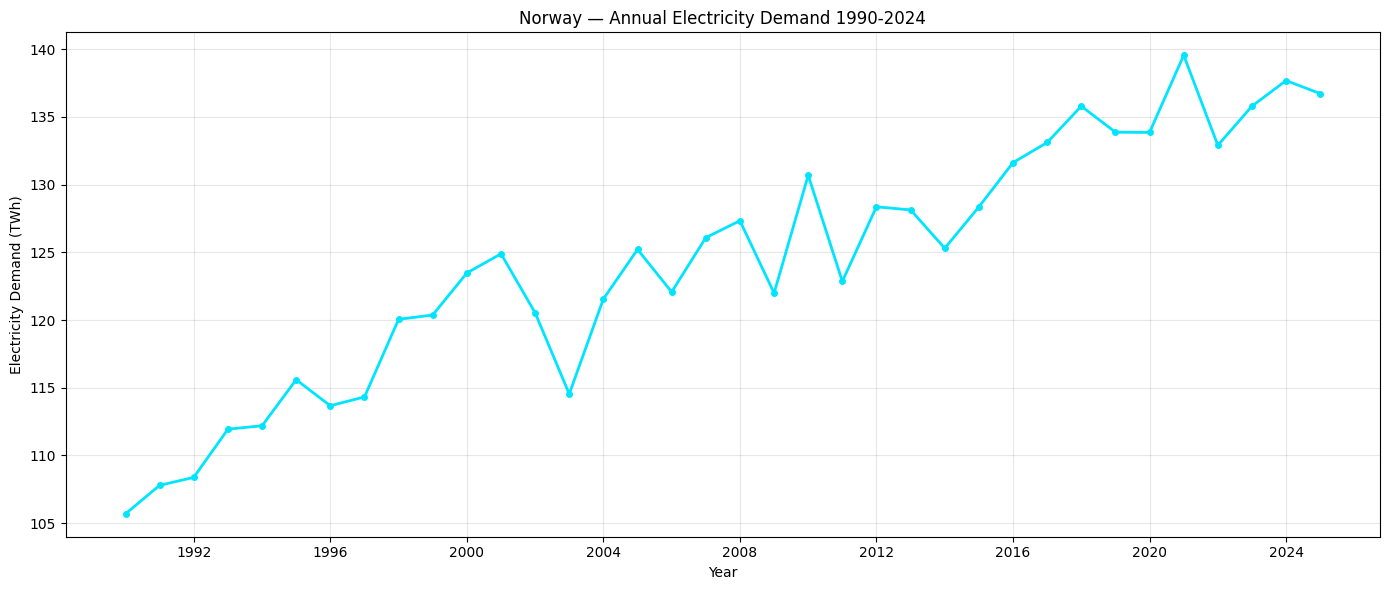

1990 demand: 105.7 TWh
Latest demand: 136.7 TWh
Change over period: 31.0 TWh


In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(norway_prophet['ds'], norway_prophet['y'],
         color='#00e5ff', linewidth=2, marker='o', markersize=4)
plt.title('Norway — Annual Electricity Demand 1990-2024')
plt.xlabel('Year')
plt.ylabel('Electricity Demand (TWh)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Basic trend statistics
print(f"1990 demand: {norway_prophet.iloc[0]['y']:.1f} TWh")
print(f"Latest demand: {norway_prophet.iloc[-1]['y']:.1f} TWh")
print(f"Change over period: {norway_prophet.iloc[-1]['y'] - norway_prophet.iloc[0]['y']:.1f} TWh")

In [ ]:
# Train on data up to 2020, test on 2021-2023
train = norway_prophet[norway_prophet['ds'] < '2021-01-01']
test = norway_prophet[norway_prophet['ds'] >= '2021-01-01']

print(f"Training period: {train['ds'].min().year} to {train['ds'].max().year}")
print(f"Test period: {test['ds'].min().year} to {test['ds'].max().year}")
print(f"Training years: {len(train)}")
print(f"Test years: {len(test)}")

# Build model
model_energy = Prophet(
    yearly_seasonality=False,  # annual data so no seasonality to detect
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.1  # conservative — we expect a stable trend
)

model_energy.fit(train)

# Forecast 10 years into the future from training cutoff
future_energy = model_energy.make_future_dataframe(
    periods=len(test) + 10,  # test period + 10 future years
    freq='Y'
)

forecast_energy = model_energy.predict(future_energy)

# Accuracy on test period only
forecast_test = forecast_energy[
    forecast_energy['ds'] >= '2021-01-01'
].head(len(test)).reset_index(drop=True)

mae = mean_absolute_error(test['y'].values, forecast_test['yhat'].values)
print(f"\nMean Absolute Error: {mae:.1f} TWh")
print(f"Average actual demand in test period: {test['y'].mean():.1f} TWh")
print(f"Error as % of actual: {mae/test['y'].mean()*100:.1f}%")

INFO:prophet:n_changepoints greater than number of observations. Using 23.


Training period: 1990 to 2020
Test period: 2021 to 2025
Training years: 31
Test years: 5

Mean Absolute Error: 2.7 TWh
Average actual demand in test period: 136.5 TWh
Error as % of actual: 2.0%


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


In [ ]:
print(f"Average predicted: {forecast_test['yhat'].mean():.1f} TWh")
print(f"Average actual: {test['y'].mean():.1f} TWh")

Average predicted: 137.8 TWh
Average actual: 136.5 TWh


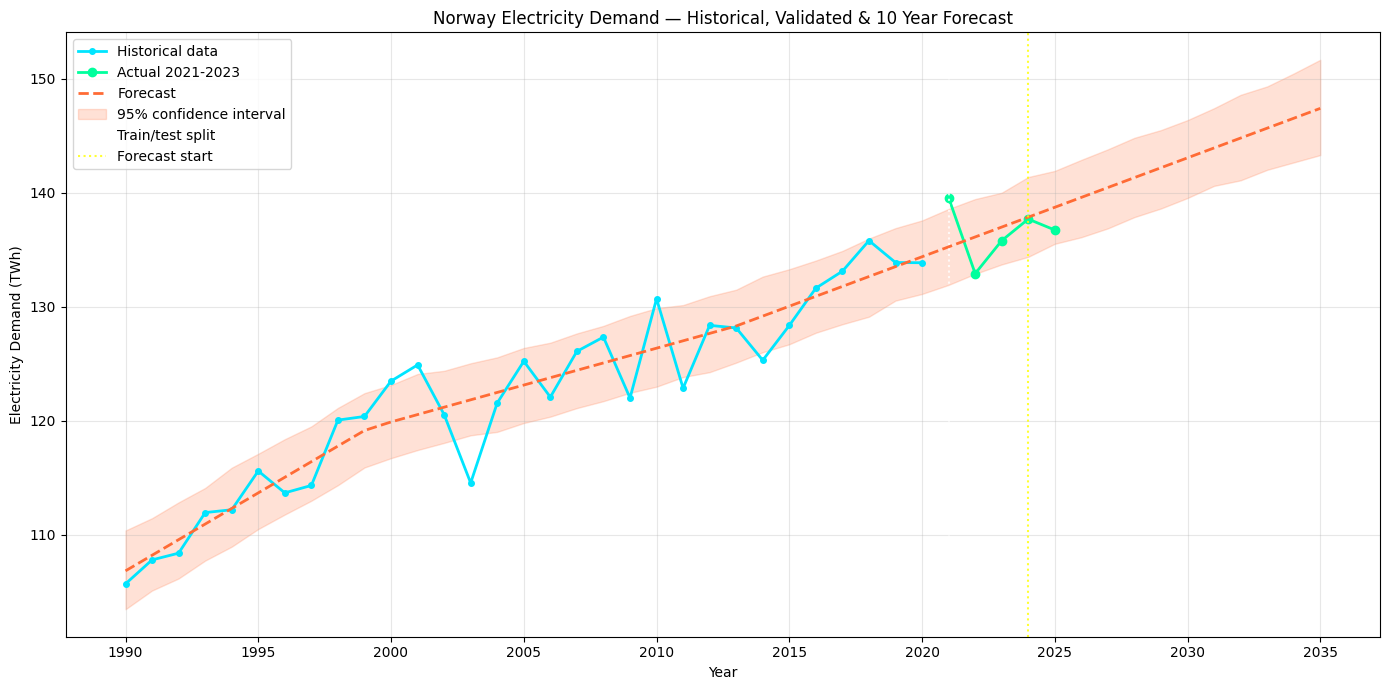

In [ ]:
plt.figure(figsize=(14, 7))

# Historical training data
plt.plot(train['ds'], train['y'],
         color='#00e5ff', linewidth=2,
         marker='o', markersize=4, label='Historical data')

# Actual test period
plt.plot(test['ds'], test['y'],
         color='#00ff9d', linewidth=2,
         marker='o', markersize=6, label='Actual 2021-2023')

# Full forecast including future
plt.plot(forecast_energy['ds'], forecast_energy['yhat'],
         color='#ff6b35', linewidth=2,
         linestyle='--', label='Forecast')

# Confidence interval
plt.fill_between(forecast_energy['ds'],
                  forecast_energy['yhat_lower'],
                  forecast_energy['yhat_upper'],
                  alpha=0.2, color='#ff6b35',
                  label='95% confidence interval')

# Mark train/test boundary
plt.axvline(x=pd.Timestamp('2021-01-01'),
            color='white', linewidth=1.5,
            linestyle=':', alpha=0.8, label='Train/test split')

# Mark where test ends and future begins
plt.axvline(x=pd.Timestamp('2024-01-01'),
            color='yellow', linewidth=1.5,
            linestyle=':', alpha=0.8, label='Forecast start')

plt.title("Norway Electricity Demand — Historical, Validated & 10 Year Forecast")
plt.xlabel('Year')
plt.ylabel('Electricity Demand (TWh)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Replace periods=len(test) + 10 with periods=len(test) + 30
future_energy = model_energy.make_future_dataframe(
    periods=len(test) + 30,  # 30 years into the future instead of 10
    freq='Y'
)

forecast_2050 = model_energy.predict(future_energy)

# What does the model predict for 2050 specifically?
prediction_2050 = forecast_2050[
    forecast_2050['ds'].dt.year == 2050
][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

print("Norway electricity demand forecast for 2050:")
display(prediction_2050.round(1))

Norway electricity demand forecast for 2050:


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


,ds,yhat,yhat_lower,yhat_upper
61,2050-12-31,161.3,154.1,167.9
